# Grid Plot Example: Consistency vs Performance

This notebook demonstrates the use of `plot_consistency_vs_performance_grid()` function to create a grid of subplots showing consistency vs performance across multiple augmentation strengths and target datasets.

## Overview
- **Rows**: Each row represents one augmentation strength
- **Columns**: Each column represents one target dataset
- **Legend**: Single legend for the entire figure showing all models
- **Correlation Stats**: Each subplot shows Kendall tau, Spearman rho, and Pearson correlation

In [1]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    plot_consistency_vs_performance_grid,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2025-11-18 15:32:25,029 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define Parameters

In [ ]:
# Paths to data
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores.json"
base_consistency_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB"

# Augmentation strengths to plot (rows)
selected_augmentations = ["a0001", "a0005", "a001", "a002", "a003", "a004", "a005", "a01"]

# Target datasets (columns)
target_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]

# Custom labels for models
custom_labels = {
    "E_model_NA2": "EPFL U-Net (No Augs)",
    "E_model_Res1": "EPFL Residual U-Net",
    "E_model5": "EPFL U-Net",
    "E_model_Unetr2": "EPFL UNETR",
    "Hm_model_NA2": "Hmito U-Net (No Augs)",
    "Hm_model4": "Hmito U-Net",
    "Hm_model_Res1": "Hmito Residual U-Net",
    "Hm_model_Unetr2": "Hmito UNETR",
    "Rm_model_NA2": "Rmito U-Net (No Augs)",
    "Rm_model4": "Rmito U-Net",
    "Rm_model_Res1": "Rmito Residual U-Net",
    "Rm_model_Unetr2": "Rmito UNETR",
    "V_model_NA2": "VNC U-Net (No Augs)",
    "V_model2": "VNC U-Net",
    "V_model_Res1": "VNC Residual U-Net"
}

## Example 1: Basic Grid Plot

Create a grid plot with default settings.

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB/transfer_performance_F1_scores.json


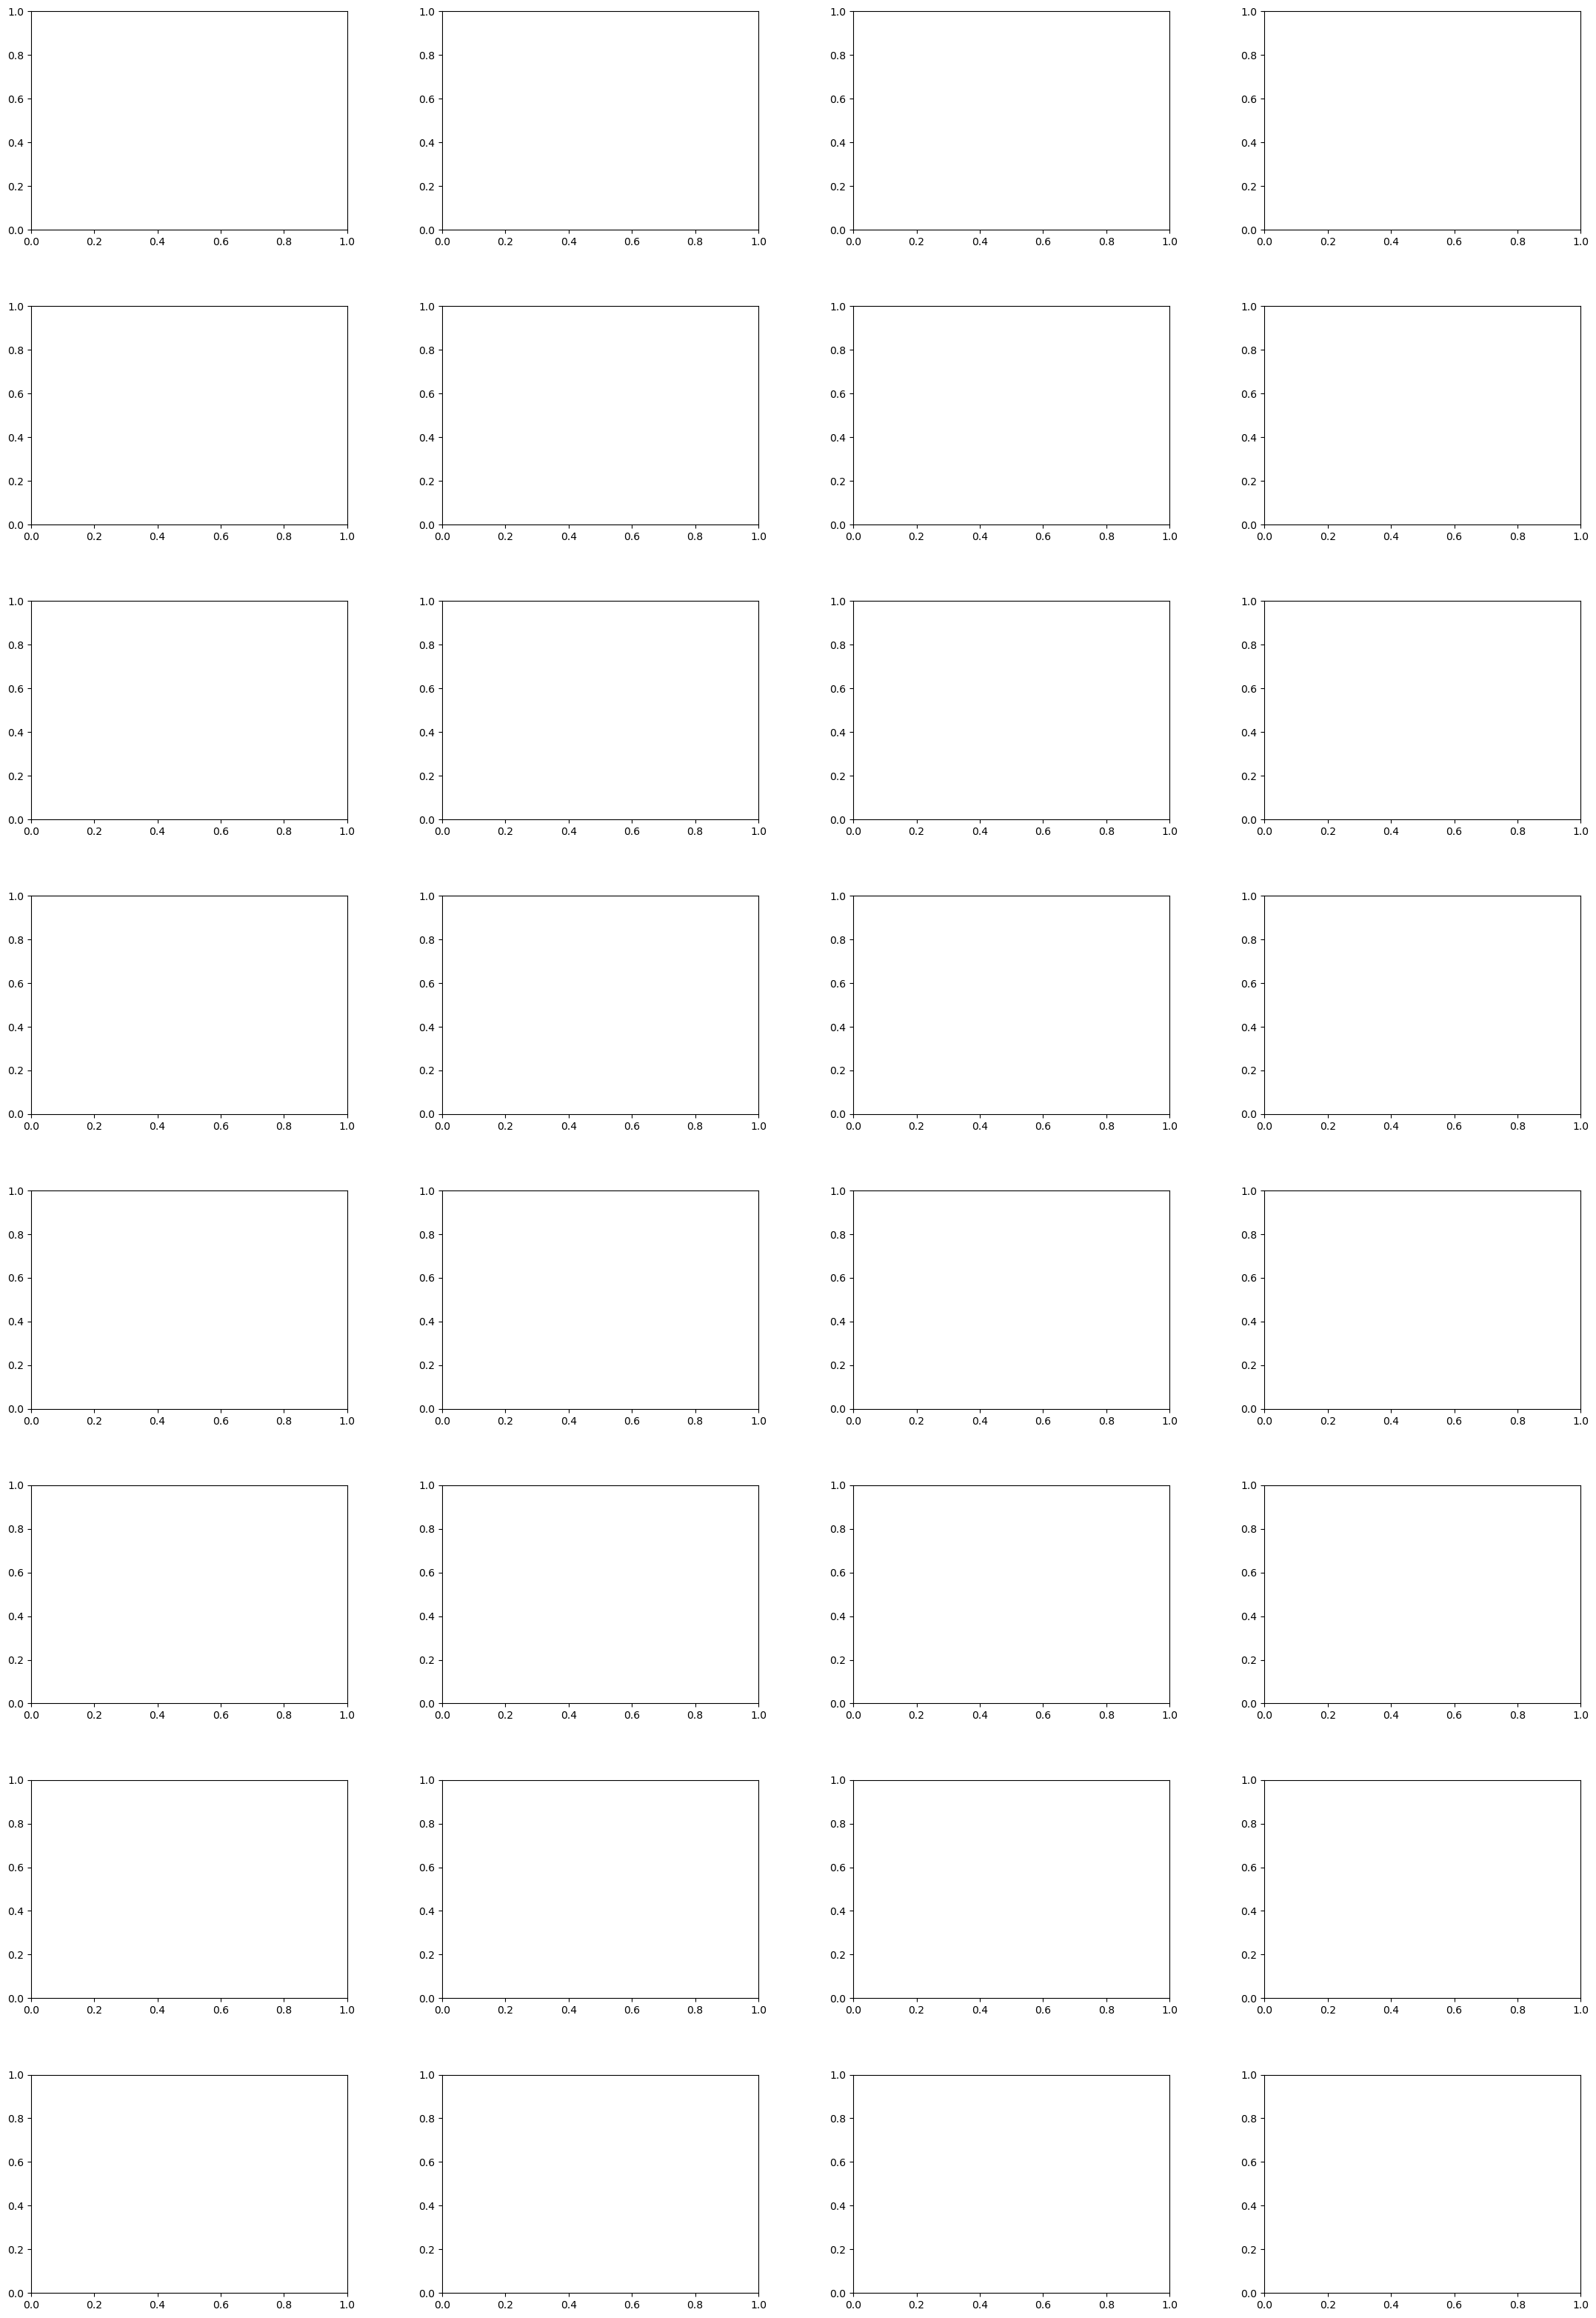

In [8]:
fig, axes = plot_consistency_vs_performance_grid(
    augmentation_strengths=selected_augmentations,
    target_datasets=target_datasets,
    performance_path=performance_path,
    base_consistency_path=base_consistency_path,
    custom_legend_labels=custom_labels,
    perturbation_type="DO",
    file_name_postfix="CMB_05f_05b_EI_scores",
    performance_score_key="F1",
)

## Example 2: Customized Grid Plot

Create a grid plot with custom styling, font sizes, and save to file.

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/feature_perturbation_consistency/direct/EI_consistency/transfer_performance_scores.json
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/feature_perturbation_consistency/direct/EI_consistency/transfer_DO_a0001_AllLayers_CMB_05f_05b_EI_scores.json
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/feature_perturbation_consistency/direct/EI_consistency/transfer_DO_a0001_AllLayers_CMB_05f_05b_EI_scores.json
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/feature_perturbation_consistency/direct/EI_consistency/transfer_DO_a0005_AllLayers_CMB_05f_05b_EI_scores.json
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentati

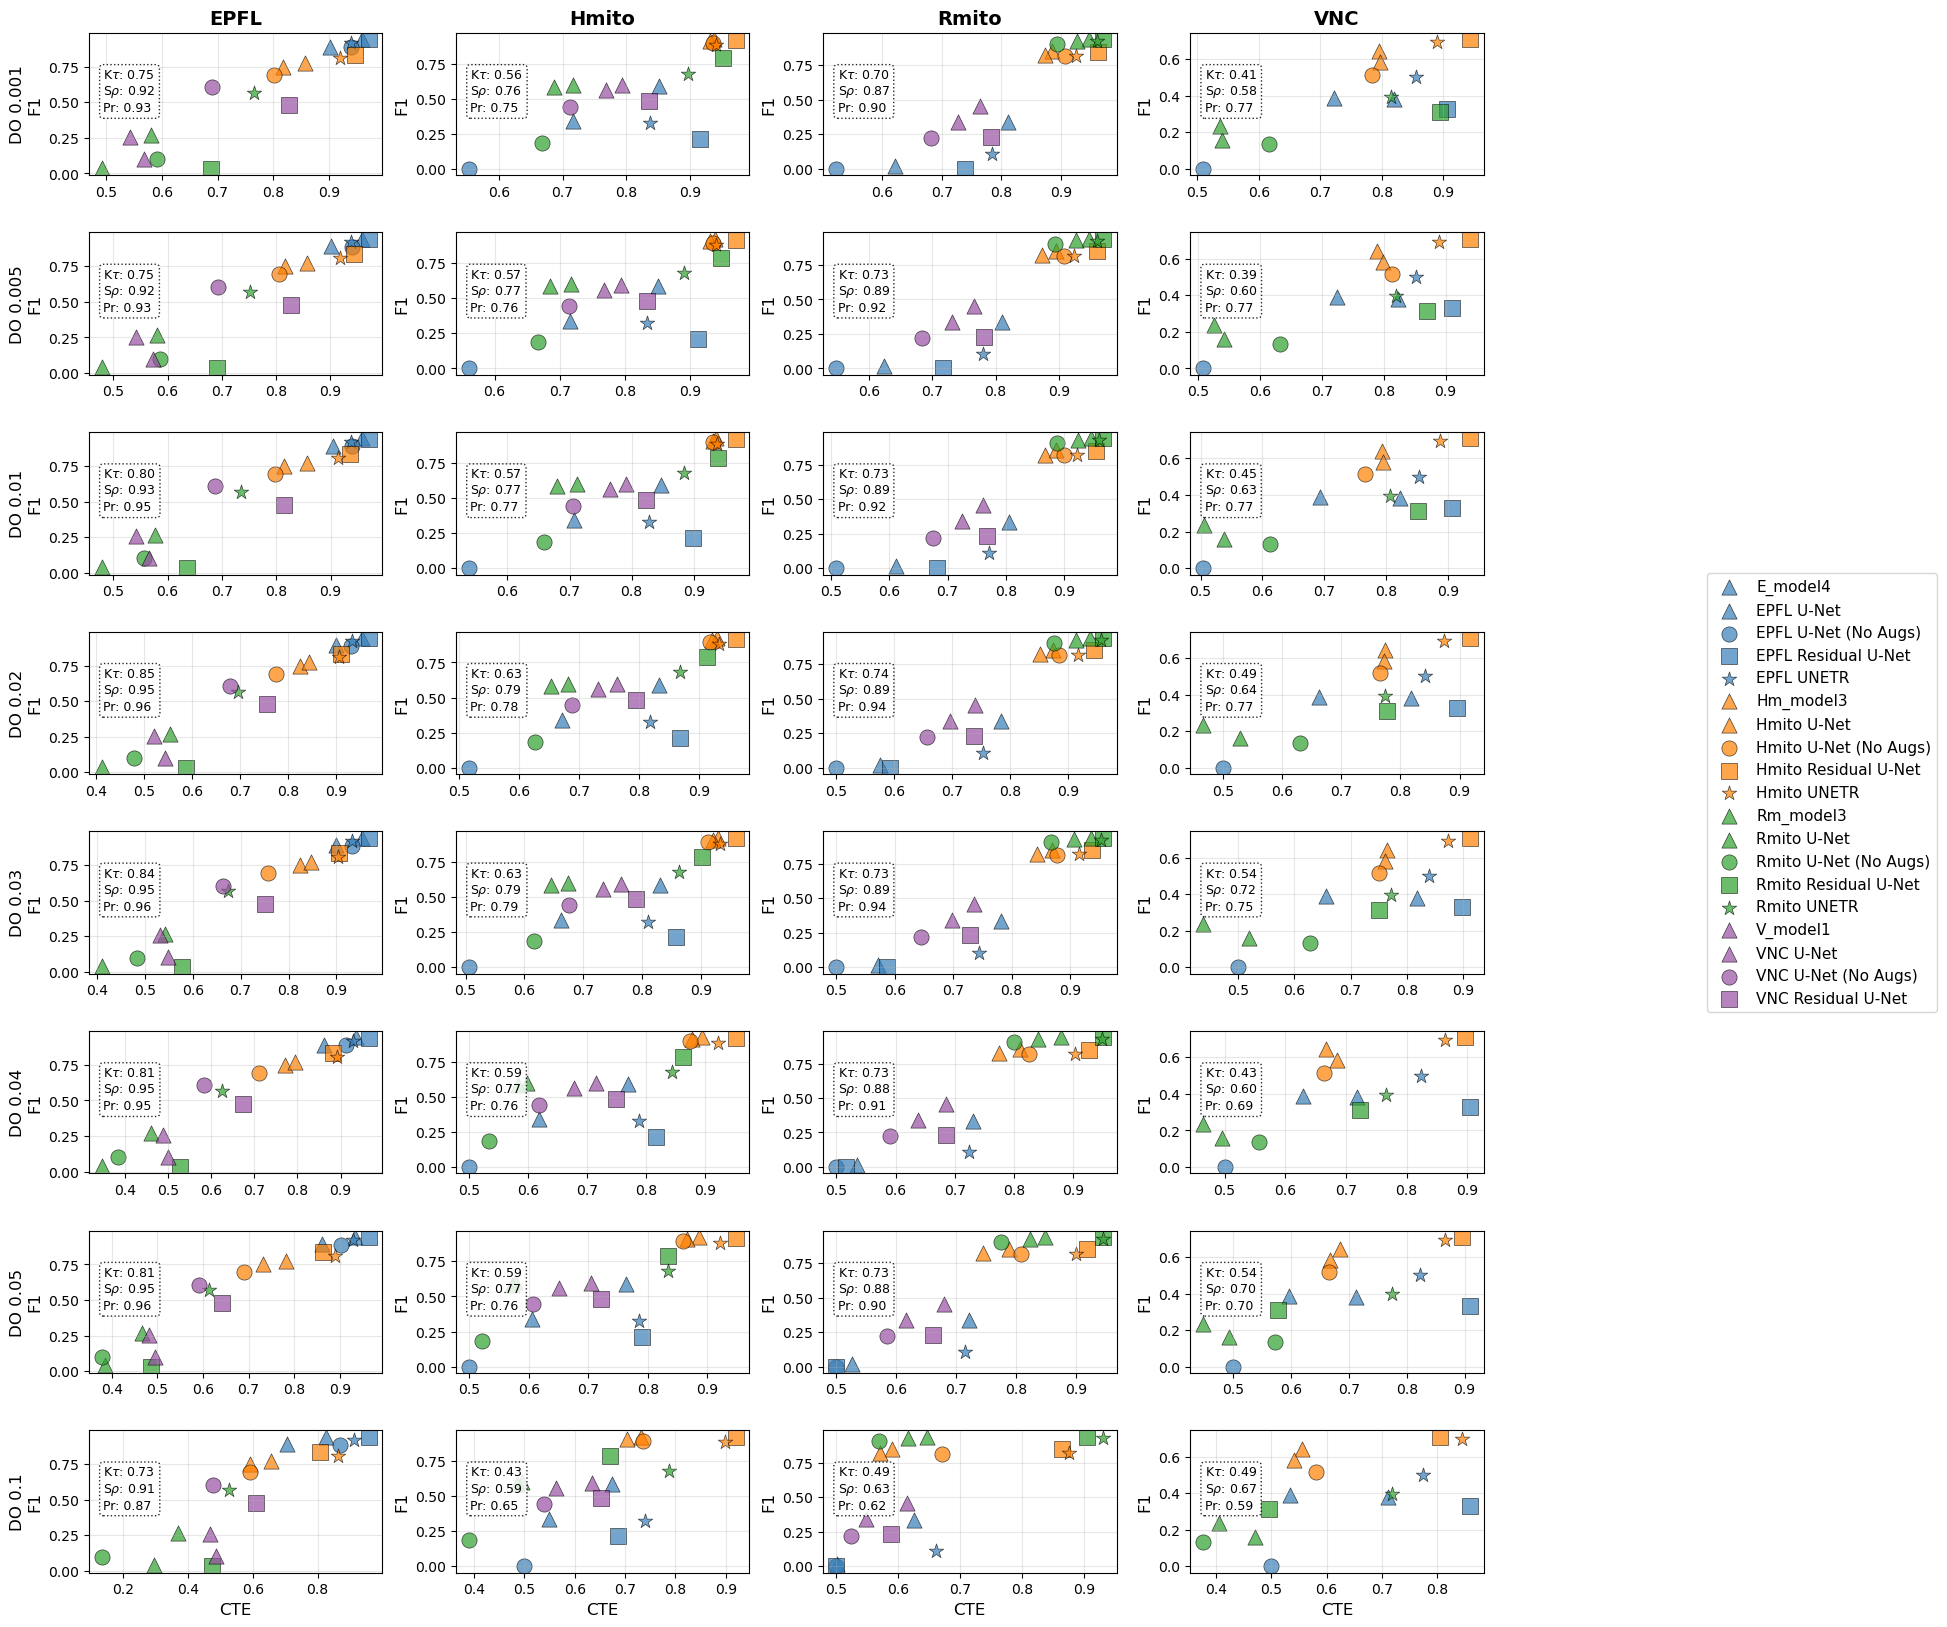

In [4]:
fig, axes = plot_consistency_vs_performance_grid(
    augmentation_strengths=selected_augmentations,
    target_datasets=target_datasets,
    performance_path=performance_path,
    base_consistency_path=base_consistency_path,
    custom_legend_labels=custom_labels,
    perturbation_type="DO",
    file_name_postfix="AllLayers_CMB_05f_05b_EI_scores",
    performance_score_key="F1",
    # Styling options
    figsize=(18, 20),  # Larger figure
    marker_size=120,
    alpha=0.7,
    # Font sizes
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=10,
    corr_fontsize=9,
    legend_fontsize=11,
    # Legend positioning
    legend_bbox_to_anchor=(1.02, 0.5),
    legend_loc="center left",
    # Correlation box positioning
    corr_box_loc=(0.05, 0.75),
    # Spacing
    wspace=0.25,
    hspace=0.4,
    # Save path
    save_path="./figures/mito_consistency_grid_DO_all_strengths",
)

## Example 3: Subset of Augmentation Strengths

Plot only a few augmentation strengths for a more compact figure.

In [ ]:
# Select only 4 augmentation strengths
subset_augmentations = ["a0001", "a001", "a003", "a01"]

fig, axes = plot_consistency_vs_performance_grid(
    augmentation_strengths=subset_augmentations,
    target_datasets=target_datasets,
    performance_path=performance_path,
    base_consistency_path=base_consistency_path,
    custom_legend_labels=custom_labels,
    perturbation_type="DO",
    file_name_postfix="AllLayers_CMB_05f_05b_EI_scores",
    performance_score_key="F1",
    figsize=(18, 12),
    marker_size=150,
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=10,
    corr_fontsize=10,
    legend_fontsize=12,
)

## Example 4: Generate Correlation Tables

Optionally, you can also generate correlation tables for each augmentation strength.
While these are not required for the grid plot, they provide additional statistical information.

In [ ]:
# Load performance scores
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

# Generate correlation tables for each augmentation
correlation_dfs = []

for aug in selected_augmentations:
    file_name = f"transfer_DO_{aug}_AllLayers_CMB_05f_05b_EI_scores.json"
    consistency_path = Path(base_consistency_path) / file_name
    
    try:
        results = load_transfer_metric_results(consistency_path)
        consistency_scores = results["consistency_scores"]
        targets = list(consistency_scores.keys())
        
        KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
            targets=targets,
            transfer_metric_per_target=consistency_scores,
            performance_per_target=performance_scores,
        )
        
        correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
        correlation_dfs.append(correlation_df)
        
        print(f"\n{'='*60}")
        print(f"Augmentation: {aug}")
        print(f"{'='*60}")
        print(correlation_df)
    except Exception as e:
        print(f"Error processing {aug}: {e}")
        correlation_dfs.append(None)

## Example 5: Different Plotting Styles

Try different matplotlib styles for publication-ready figures.

In [ ]:
# Colorblind-friendly style
fig, axes = plot_consistency_vs_performance_grid(
    augmentation_strengths=subset_augmentations,
    target_datasets=target_datasets,
    performance_path=performance_path,
    base_consistency_path=base_consistency_path,
    custom_legend_labels=custom_labels,
    perturbation_type="DO",
    file_name_postfix="AllLayers_CMB_05f_05b_EI_scores",
    performance_score_key="F1",
    plot_style="seaborn-v0_8-colorblind",  # Colorblind-friendly
    figsize=(18, 12),
    marker_size=150,
)

## Example 6: Focus on Specific Target Datasets

You can also plot a subset of target datasets.

In [ ]:
# Plot only EPFL and Hmito
fig, axes = plot_consistency_vs_performance_grid(
    augmentation_strengths=selected_augmentations,
    target_datasets=["EPFL", "Hmito"],  # Only 2 columns
    performance_path=performance_path,
    base_consistency_path=base_consistency_path,
    custom_legend_labels=custom_labels,
    perturbation_type="DO",
    file_name_postfix="AllLayers_CMB_05f_05b_EI_scores",
    performance_score_key="F1",
    figsize=(12, 20),  # Narrower figure for 2 columns
    marker_size=180,
    title_fontsize=14,
    label_fontsize=12,
)

## Summary

The `plot_consistency_vs_performance_grid()` function provides:

1. **Multi-subplot layout**: Easily compare consistency vs performance across multiple augmentation strengths and target datasets
2. **Consistent styling**: All subplots use the same color scheme and marker shapes as `plot_single_consistency_vs_performance_CVPR_shapes()`
3. **Shape-based architecture distinction**:
   - Circle (○): U-Net (No Augs)
   - Square (■): ResUNet
   - Star (★): UNETR
   - Triangle (▲): U-Net
4. **Single legend**: One legend for the entire figure showing all models
5. **Correlation statistics**: Each subplot displays Kendall tau, Spearman rho, and Pearson correlation
6. **Flexible customization**: Control font sizes, marker sizes, colors, spacing, and more
7. **Automatic saving**: Saves both PNG (300 DPI) and SVG versions

### Key Parameters:
- `augmentation_strengths`: List of augmentation identifiers (determines number of rows)
- `target_datasets`: List of target dataset names (determines number of columns)
- `custom_legend_labels`: Dictionary mapping model names to display names
- `figsize`: Figure size (auto-calculated if not provided)
- Font size parameters: `title_fontsize`, `label_fontsize`, `tick_fontsize`, `corr_fontsize`, `legend_fontsize`
- `save_path`: Path to save figure (optional)